In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import RandomSampler
from sklearn.preprocessing import (
    OneHotEncoder,  
    OrdinalEncoder, 
    PowerTransformer, 
    MinMaxScaler,
    RobustScaler
)

from sklearn.model_selection import train_test_split, TunedThresholdClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    balanced_accuracy_score, 
    f1_score, 
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)


## Load Data

In [2]:
us_visa_data = pd.read_csv("EasyVisa.csv")
us_visa_data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


## Data Cleaning

During initial analysis we found that that the `case_id` has only unique values therefore high variance which is normal given that it's the unique identifier of each visa application however this feature is not useful for modeling so it can be safely removed. We also saw that sone of the records have negative values for the `no_of_employees` feature. It seems that this is a mistake during data collection since there is no pattern in the data that can suggest other reason. These records are very few so they can be safely removed too. 

In [3]:
us_visa_data = us_visa_data.drop(columns=["case_id"])

negative_no_employees = us_visa_data[us_visa_data["no_of_employees"] < 0 ].index
us_visa_data = us_visa_data.drop(negative_no_employees)

us_visa_data.shape

(25447, 11)

## Feature Engineering

In [4]:
from datetime import date

today_date = date.today()
current_year = today_date.year

# Creating a campany age feature to facilitate any future models
us_visa_data["company_age"] = current_year - us_visa_data["yr_of_estab"] 
us_visa_data = us_visa_data.drop(columns=["yr_of_estab"])

us_visa_data.shape

(25447, 11)

## Preprocessing

Before training any machine learning model the data has to be in a suitable format for this task. Machine learning models work only with numbers and don't know what to do with categories so categorical features have to be encoded in some way. Also some models don't work well with numerical features that are on vastly different scales and those features have to be rescaled to some range.

In [5]:
numeric_features = [feature for feature in us_visa_data.columns if us_visa_data[feature].dtype != 'str']
ohe_features = [
    "continent", 
    "has_job_experience", 
    "requires_job_training", 
    "region_of_employment", 
    "unit_of_wage", 
    "full_time_position"
]

# The categories inside education_of_employee have an inherent order 
# (e.g. High School education is lower than Bachelor's degree etc.)
ordinal_features = ["education_of_employee"]
target_column = "case_status"
education_categories = ["High School", "Bachelor's", "Master's", "Doctorate"]

numeric_pipeline = Pipeline(steps=[
    # Makes skewed distributions more Gaussian-like. Many algorithms assume normally distributed data
    ("log_transform", PowerTransformer(standardize=False)),
    
    # Scales the data to be in the range between 0 and 1
    # Suitable for normally distributed data with no outliers 
    ("scale", MinMaxScaler())])

ohe_pipeline = Pipeline([
    # Creates a new binary column for each category
    ("ohe", OneHotEncoder(sparse_output=False, drop="first"))
])

ordinal_pipeline = Pipeline(steps=[
    ("encode", OrdinalEncoder(categories=[education_categories]))
]) 

transformer = ColumnTransformer([
    ("numeric_pipeline", numeric_pipeline, numeric_features),
    ("ohe_pipeline", ohe_pipeline, ohe_features),
    ("ordinal_pipeline", ordinal_pipeline, ordinal_features)
])

# Encoding the target column as binary labels (0 -> Denied, 1 -> Certified)
us_visa_data["case_status"] = us_visa_data["case_status"].apply(lambda row: 0 if row == "Denied" else 1)

In [6]:
us_visa_data["case_status"]

0        0
1        1
2        0
3        0
4        1
        ..
25475    1
25476    1
25477    1
25478    1
25479    1
Name: case_status, Length: 25447, dtype: int64

## Model Building

### Train, Validation and Test Splits

In this step the data is split into the training, validation and test sets. The training set is used to train models to learn from data, the validation set is to compare the performance of different models and evaluation after training and after hyperparameter tuning and select the best model for final evaluation.

The test set remains hidden from the model during training and evaluation and is used for assesing modle generalization on new unseen data. A good rule of thumb is that the test should be 20% of the whole data set but this number can vary. But here the more important idea is that the test set should be small enough to leave enough records for training and validation but not too small since it could be unstable and not repesentative of the entire dataset. Cross-validation is not needed here since there are enough samples in the dataset.

In [7]:
visa_attributes = us_visa_data.drop(columns=target_column) # Input features
visa_target = us_visa_data[target_column] # Target column

attributes_train_and_val, attributes_test, target_train_and_val, target_test = train_test_split(
    visa_attributes, 
    visa_target, 
    test_size=0.2, 
    stratify=visa_target,
    shuffle=True,
    random_state=42
)

attributes_train, attributes_val, target_train, target_val = train_test_split(
    attributes_train_and_val, 
    target_train_and_val,
    test_size=4000,
    stratify=target_train_and_val, 
    shuffle=True,
    random_state=42
)

print(attributes_train_and_val.shape, attributes_test.shape, target_train_and_val.shape, target_test.shape)
print(attributes_train.shape, attributes_val.shape, target_train.shape, target_val.shape)

(20357, 10) (5090, 10) (20357,) (5090,)
(16357, 10) (4000, 10) (16357,) (4000,)


In [8]:
test_set = pd.concat([attributes_test, target_test], axis=1)
test_set.to_csv("test.csv", index=False)

del test_set
del attributes_test
del target_test

### Evaluation Metrics

Given the imbalanced dataset some suitable metrics for this case are __roc_auc_score__,  __balanced accuracy__ and __f1_score__

- **balanced accuracy**: the average recall for each class. This is our main metric
- **f1_score**: the harmonic mean of precision and recall. It is suitable for cases where precision and recall are of equal importance
- **roc_auc_score**: the area under the Receiver Operating Characteristic (ROC) curve. This metric compares the true positive and false positive rate at various classification thresholds.

### Dummy Model

The first model is a simple dummy model that predicts the most common class. It has high bias as expected since it doesn't learn anything interesting from the data besides the most common label. It achived a balanced accuracy score of 50% and  a f1 score of 80%.

In [9]:
base_pipeline = Pipeline([
    ("transform", transformer),
    # A simple model with no learning capacity to serve as baseline for later comparison 
    ("model", DummyClassifier(strategy="most_frequent"))
])

base_pipeline.fit(attributes_train, target_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transform', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_pipeline', ...), ('ohe_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [10]:
train_accuracy = balanced_accuracy_score(target_train, base_pipeline.predict(attributes_train))
train_f1_score = f1_score(target_train, base_pipeline.predict(attributes_train))
train_roc_auc = roc_auc_score(target_train, base_pipeline.predict_proba(attributes_train)[:, 1])

print(f"Train set balanced accuracy score: {train_accuracy:.4f}")
print(f"Train set f1 score: {train_f1_score:.4f}")
print(f"Train set ROC AUC score: {train_roc_auc}")

Train set balanced accuracy score: 0.5000
Train set f1 score: 0.8010
Train set ROC AUC score: 0.5


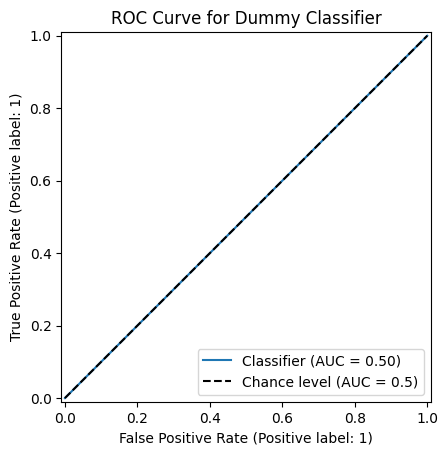

In [11]:
RocCurveDisplay.from_predictions(
    target_train, 
    base_pipeline.predict_proba(attributes_train)[:, 1], 
    plot_chance_level=True
)
plt.title("ROC Curve for Dummy Classifier")
plt.show()

### Linear Support Vector Classifier

The next model is a Support Vector Classifier. It performs better than the baseline but also seems to have high bias. The results for both training and validation sets and both metrics are very similar which indicates that probably the default regulariation strenght is too high.

In [12]:
svm_pipeline = Pipeline([
    ("transform", transformer),
    # A more complex linear model with a good performance both for categorical and numeric features
    ("model", LinearSVC(random_state=42))
])

svm_pipeline.fit(attributes_train, target_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transform', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_pipeline', ...), ('ohe_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [13]:
train_accuracy = balanced_accuracy_score(target_train, svm_pipeline.predict(attributes_train))
train_f1_score = f1_score(target_train, svm_pipeline.predict(attributes_train))
train_roc_auc = roc_auc_score(target_train, svm_pipeline.decision_function(attributes_train))

print(f"Train set balanced accuracy score: {train_accuracy:.4f}")
print(f"Train set f1 score: {train_f1_score:.4f}")
print(f"Train set ROC AUC score: {train_roc_auc:.4f}")

Train set balanced accuracy score: 0.6543
Train set f1 score: 0.8148
Train set ROC AUC score: 0.7625


In [14]:
val_accuracy = balanced_accuracy_score(target_val, svm_pipeline.predict(attributes_val))
val_f1_score = f1_score(target_val, svm_pipeline.predict(attributes_val))
val_roc_auc_score = roc_auc_score(target_val, svm_pipeline.decision_function(attributes_val))

print(f"Validation set balanced accuracy score: {val_accuracy:.4f}")
print(f"Validation set f1 score: {val_f1_score:.4f}")
print(f"Validation set ROC AUC score: {val_roc_auc_score:.4f}")

Validation set balanced accuracy score: 0.6634
Validation set f1 score: 0.8208
Validation set ROC AUC score: 0.7696


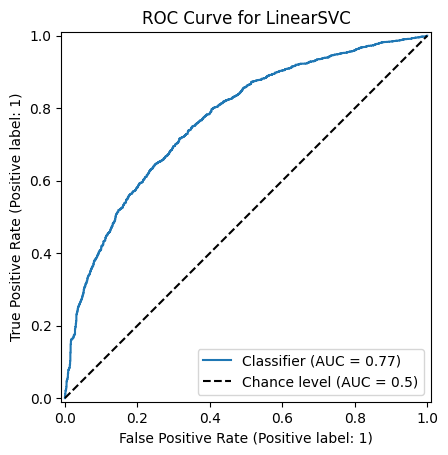

In [15]:
RocCurveDisplay.from_predictions(
    target_val, 
    svm_pipeline.decision_function(attributes_val),
    plot_chance_level=True
)
plt.title("ROC Curve for LinearSVC")
plt.show()

### Decision Tree Classifier

The next model is a DecisionTreeClassifier. This model perform better than the LinearSVC model but has high variance and overfits on the training data and doesn't perform well on the validation data. This happens because an unregularized tree can grow infinately deep untill the leaf nodes at the bottom level contain only pure samples and  absolutely perfect classification. 

In [16]:
tree_pipeline = Pipeline([
    ("transform", transformer),
    # A more complex model with a good performance on data with mainly categorical features.
    # Most probably will overfit the training data
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_pipeline.fit(attributes_train, target_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transform', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_pipeline', ...), ('ohe_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [17]:
train_accuracy = balanced_accuracy_score(target_train, tree_pipeline.predict(attributes_train))
train_f1_score = f1_score(target_train, tree_pipeline.predict(attributes_train))
train_roc_auc = roc_auc_score(target_train, tree_pipeline.predict_proba(attributes_train)[:, 1])

print(f"Train set balanced accuracy score: {train_accuracy:.4f}")
print(f"Train set f1 score: {train_f1_score:.4f}")
print(f"Train set ROC AUC score: {train_roc_auc}")

Train set balanced accuracy score: 1.0000
Train set f1 score: 1.0000
Train set ROC AUC score: 1.0


In [18]:
val_accuracy = balanced_accuracy_score(target_val, tree_pipeline.predict(attributes_val))
val_f1_score = f1_score(target_val, tree_pipeline.predict(attributes_val))
val_roc_auc_score = roc_auc_score(target_val, tree_pipeline.predict_proba(attributes_val)[:, 1])

print(f"Validation set balanced accuracy score: {val_accuracy:.4f}")
print(f"Validation set f1 score: {val_f1_score:.4f}")
print(f"Validation set ROC AUC score: {val_roc_auc_score:.4f}")

Validation set balanced accuracy score: 0.5981
Validation set f1 score: 0.7305
Validation set ROC AUC score: 0.5981


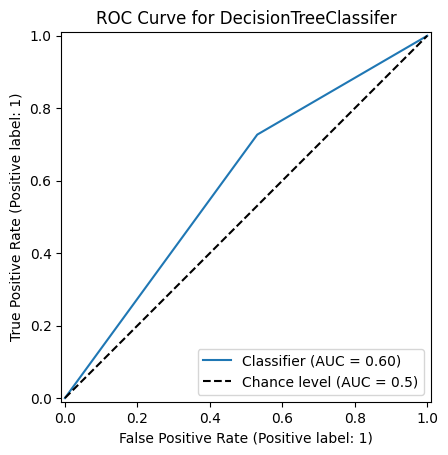

In [19]:
RocCurveDisplay.from_predictions(
    target_val, 
    tree_pipeline.predict_proba(attributes_val)[:, 1],
    plot_chance_level=True
)
plt.title("ROC Curve for DecisionTreeClassifer")
plt.show()

### Random Forest Classifier

The next model is a Random Forest Classifier. It also has high variance and overfits to the training data and doesn't perform well on the validation data. 

In [20]:
forest_pipeline = Pipeline([
    ("transform", transformer),
    
    # An ensamble model made of multiple decision trees trained on different subsets of the training data
    # Has a lower chance of overfitting to the training data.
    ("model", RandomForestClassifier(random_state=42))
])

forest_pipeline.fit(attributes_train, target_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transform', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_pipeline', ...), ('ohe_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [21]:
train_accuracy = balanced_accuracy_score(target_train, forest_pipeline.predict(attributes_train))
train_f1_score = f1_score(target_train, forest_pipeline.predict(attributes_train))
train_roc_auc = roc_auc_score(target_train, forest_pipeline.predict_proba(attributes_train)[:, 1])

print(f"Train set balanced accuracy score: {train_accuracy:.4f}")
print(f"Train set f1 score: {train_f1_score:.4f}")
print(f"Train set ROC AUC score: {train_roc_auc:.4f}")

Train set balanced accuracy score: 1.0000
Train set f1 score: 1.0000
Train set ROC AUC score: 1.0000


In [22]:
val_accuracy = balanced_accuracy_score(target_val, forest_pipeline.predict(attributes_val))
val_f1_score = f1_score(target_val, forest_pipeline.predict(attributes_val))
val_roc_auc = roc_auc_score(target_val, forest_pipeline.predict_proba(attributes_val)[:, 1])

print(f"Validation set balanced accuracy score: {val_accuracy:.4f}")
print(f"Validation set f1 score: {val_f1_score:.4f}")
print(f"Validation set ROC AUC score: {val_roc_auc:.4f}")

Validation set balanced accuracy score: 0.6688
Validation set f1 score: 0.8061
Validation set ROC AUC score: 0.7558


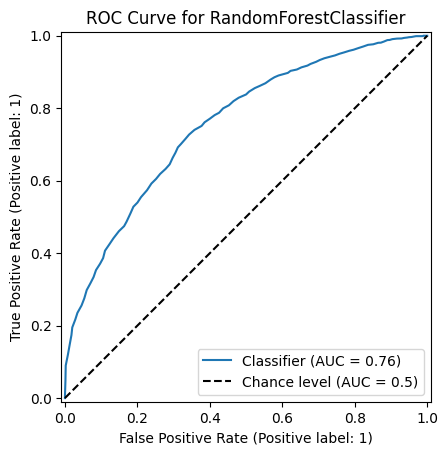

In [23]:
RocCurveDisplay.from_predictions(
    target_val, 
    forest_pipeline.predict_proba(attributes_val)[:, 1],
    plot_chance_level=True
)
plt.title("ROC Curve for RandomForestClassifier")
plt.show()

## Hyperparameter Tuning

Let's try to squeeze out some more performance from the model using hyperparameter tuning. For this task the `optuna` package is used instead of scikit-learn's methods like `GridSearchCV` and `RandomizedSearchCV` since it provides more efficent algorithms for hyperparameter tuning.

Even though `optuna` is better optimized hyperparameter tuning still takes time so only RandomForestClassifer and LinearSVC models are tuned. The other models are skipped since the dummy model is only used as baseline for comparison and doesn't actually learn anything form the data and it doesn't have any hyperparameters; the DecisionTreeClassifer has similar hyperprameters as the RandomForestClassifier and their effect is the same.

We are optimizing for the f1_score since it gives equal imprtnace to false negatives and false positives.

In [24]:
def objective(trial):
    classifier_name = trial.suggest_categorical("classifer", ["LinearSVC", "RandomForest"])
    classifier_obj = None

    # Hyperparameters to optimize
    if classifier_name == "RandomForest":
        # Controls the number of decision trees in the ensamble. 
        # Smaller number leads to simplier model with less chance of overfitting
        n_estimators = trial.suggest_int("n_estimators", 50, 500)
    
        # Controls the depth of each tree in the ensamble
        max_depth = trial.suggest_int("max_depth", 2, 10)
    
        # Controls the minimum number of samples required to split an internal node
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    
        # Controls the minimum number of samples required to be at a leaf node
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
        classifier_obj = Pipeline([
            ("transform", transformer),
            ("model", RandomForestClassifier(
                n_estimators=n_estimators, 
                max_depth=max_depth, 
                min_samples_split=min_samples_split, 
                min_samples_leaf=min_samples_leaf,
                random_state=42
            ))
        ])

    else:
        # Controls the regularization strength of the model.
        # Smaller number means stronger regularization and risk of underfitting, 
        # larger number means weaker regularization and risk of overfitting
        svm_c = trial.suggest_float('svm_c', 1e-10, 1e10, log=True)
        classifier_obj = Pipeline([
            ("transform", transformer),
            ("model", LinearSVC(C=svm_c, random_state=42))
        ])

    classifier_obj.fit(attributes_train, target_train)
    predictions = classifier_obj.predict(attributes_val)

    score = f1_score(target_val, predictions)
    return score
        

In [25]:
# # Cerate a study object
# study = optuna.create_study(direction="maximize", sampler=RandomSampler(seed=42))

# # Begin optimization process
# study.optimize(objective, n_trials=100)

In [26]:
# best_params = study.best_params
# best_score = study.best_value

# print(f"Best hyperparameters: {best_params}")
# print(f"Best score: {best_score}")

## Final Evaluation

The best performing model seems to be the Random Forest Classifer. It achived a 66% balanced accuracy score, 83% f1 score and 79% roc auc score on the test set. The results are very simmilar to the ones on the training set but are still somewhat low 

In [27]:
us_visa_data_test = pd.read_csv("test.csv")
print(us_visa_data_test)

          continent education_of_employee has_job_experience  \
0              Asia              Master's                  N   
1              Asia            Bachelor's                  Y   
2              Asia              Master's                  Y   
3              Asia              Master's                  N   
4     North America           High School                  N   
...             ...                   ...                ...   
5085           Asia             Doctorate                  Y   
5086  South America              Master's                  Y   
5087           Asia            Bachelor's                  N   
5088           Asia             Doctorate                  N   
5089        Oceania            Bachelor's                  Y   

     requires_job_training  no_of_employees region_of_employment  \
0                        N             3675            Northeast   
1                        N            19660            Northeast   
2                        N 

In [28]:
attributes_test = us_visa_data_test.drop(columns=[target_column])
target_test = us_visa_data_test[target_column]

print(attributes_test.head())
print(target_test.head())

       continent education_of_employee has_job_experience  \
0           Asia              Master's                  N   
1           Asia            Bachelor's                  Y   
2           Asia              Master's                  Y   
3           Asia              Master's                  N   
4  North America           High School                  N   

  requires_job_training  no_of_employees region_of_employment  \
0                     N             3675            Northeast   
1                     N            19660            Northeast   
2                     N             3944                 West   
3                     Y             1851                 West   
4                     N             3512                South   

   prevailing_wage unit_of_wage full_time_position  company_age  
0       53517.9600         Year                  N           18  
1       72422.6600         Year                  Y           21  
2       75821.3600         Year             

In [29]:
best_forest_pipeline = Pipeline([
    ("transform", transformer),
    ("model", RandomForestClassifier(
        n_estimators=363,
        max_depth=7,
        min_samples_leaf=7,
        min_samples_split=2,
        random_state=42
    ))
])

best_forest_pipeline.fit(attributes_train, target_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transform', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_pipeline', ...), ('ohe_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [30]:
train_accuracy = balanced_accuracy_score(target_train, best_forest_pipeline.predict(attributes_train))
train_f1_score = f1_score(target_train, best_forest_pipeline.predict(attributes_train))
train_roc_auc = roc_auc_score(target_train, best_forest_pipeline.predict_proba(attributes_train)[:, 1])

print(f"Train set balanced accuracy score: {train_accuracy:.4f}")
print(f"Train set f1 score: {train_f1_score:.4f}")
print(f"Train set ROC AUC score: {train_roc_auc:.4f}")

Train set balanced accuracy score: 0.6718
Train set f1 score: 0.8332
Train set ROC AUC score: 0.7948


In [31]:
test_accuracy = balanced_accuracy_score(target_test, best_forest_pipeline.predict(attributes_test))
test_f1_score = f1_score(target_test, best_forest_pipeline.predict(attributes_test))
test_roc_auc = roc_auc_score(target_test, best_forest_pipeline.predict_proba(attributes_test)[:, 1])

print(f"Test set balanced accuracy score: {test_accuracy:.4f}")
print(f"Test set f1 score: {test_f1_score:.4f}")
print(f"Test set ROC AUC score: {test_roc_auc:.4f}")

Test set balanced accuracy score: 0.6639
Test set f1 score: 0.8289
Test set ROC AUC score: 0.7878


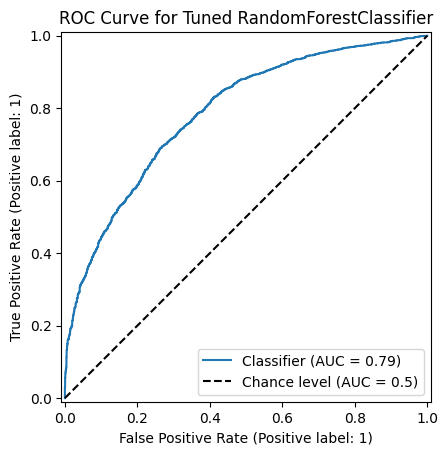

In [32]:
RocCurveDisplay.from_predictions(
    target_test, 
    best_forest_pipeline.predict_proba(attributes_test)[:, 1],
    plot_chance_level=True
)
plt.title("ROC Curve for Tuned RandomForestClassifier")
plt.show()

As seen form the confusion matrix bellow the amount of false positives is high. The could be resolved with a different classification threshold

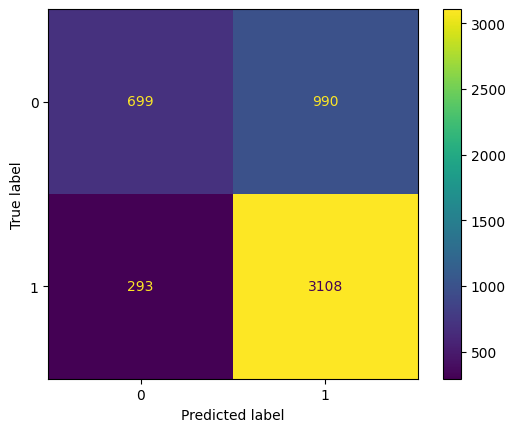

In [33]:
ConfusionMatrixDisplay.from_predictions(
    y_true=target_test,
    y_pred=best_forest_pipeline.predict(attributes_test)
)
plt.show()

## Classification Thereshold Tuning

The default classification threshold for scikit-learn estimators is 0.5, however this is rarely useful in cases of class imbalance where different misclassification errors have different costs. The optimal threshold taking into account we're optimizing for f1 score is 0.503. This means that if an appilcation has greater than 50.3% probability of being approved it is consdered approved by the classifer

In [34]:
thresholded_classifier = TunedThresholdClassifierCV(
    estimator=best_forest_pipeline,
    scoring="f1",
    random_state=42
)

thresholded_classifier.fit(attributes_train, target_train)

,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",Pipeline(step...m_state=42))])
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.",'f1'
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).",None
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary `.",42
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of

In [35]:
train_accuracy = balanced_accuracy_score(target_train, thresholded_classifier.predict(attributes_train))
train_f1_score = f1_score(target_train, thresholded_classifier.predict(attributes_train))
train_roc_auc = roc_auc_score(target_train, thresholded_classifier.predict_proba(attributes_train)[:, 1])

print(f"Train set balanced accuracy score: {train_accuracy:.4f}")
print(f"Train set f1 score: {train_f1_score:.4f}")
print(f"Train set ROC AUC score: {train_roc_auc:.4f}")

Train set balanced accuracy score: 0.6778
Train set f1 score: 0.8331
Train set ROC AUC score: 0.7948


In [36]:
test_accuracy = balanced_accuracy_score(target_test, thresholded_classifier.predict(attributes_test))
test_f1_score = f1_score(target_test, thresholded_classifier.predict(attributes_test))
test_roc_auc = roc_auc_score(target_test, thresholded_classifier.predict_proba(attributes_test)[:, 1])

print(f"Test set balanced accuracy score: {test_accuracy:.4f}")
print(f"Test set f1 score: {test_f1_score:.4f}")
print(f"Test set ROC AUC score: {test_roc_auc:.4f}")
print(f"New optimal threshold: {thresholded_classifier.best_threshold_}")

Test set balanced accuracy score: 0.6682
Test set f1 score: 0.8286
Test set ROC AUC score: 0.7878
New optimal threshold: 0.5037900858523046


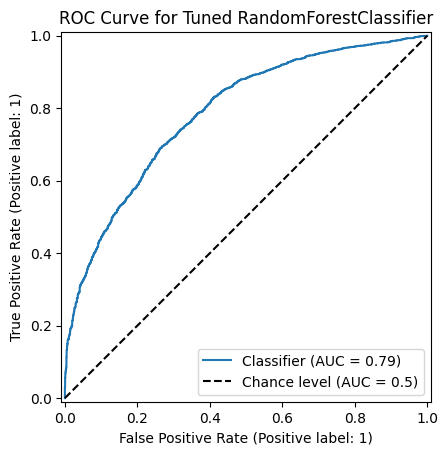

In [37]:
RocCurveDisplay.from_predictions(
    target_test, 
    best_forest_pipeline.predict_proba(attributes_test)[:, 1],
    plot_chance_level=True
)
plt.title("ROC Curve for Tuned RandomForestClassifier")
plt.show()

With the new classification threshold, the number of false negatives dropped from 990 to 966, however the number of false negatives increased from 293 to 312. The number of true negatives also increased from 699 to 723.

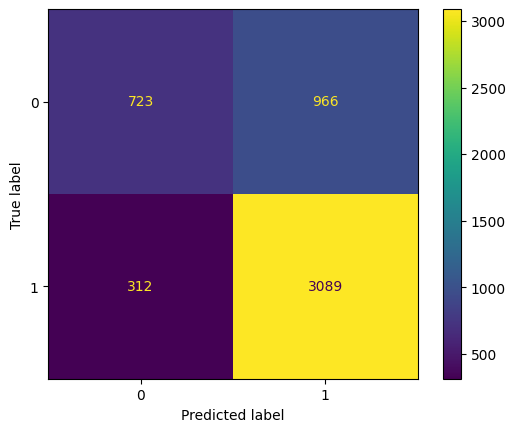

In [40]:
ConfusionMatrixDisplay.from_predictions(
    y_true=target_test,
    y_pred=thresholded_classifier.predict(attributes_test)
)
plt.show()

## Conclusion

This project attempted to solve the classification problem of classifying visa applications as cetified or denied.
Mutiple machine algorithm were tested but the best performing one proved to be the Random Forest Classifer. Some other options were:

- **Support Vector Classifer**: this model had high bias and coludn't learn the underling patterns in the data. We assumed that the underfitting problem was due to the default regularization strength beeing to high. We tuned the `C` hyperparameter of the model together with the Random Forest Classifer and the Random Forest Classifer proved to be the better choice.
- **Decision Tree Classifer**: this model had high variance and was overfitting on the training data. We slipped tuning it since it has the same hyperparameters as the Random Forest Classifer and they have the same effect.

### Next Steps
Some steps that could be taken to improve model performance could be:
- Collecing more data
- Creating more meaningful features with more careful feature engineering
- A better preprocessing pipeline